In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import mplstereonet
from scipy.stats import gaussian_kde
import warnings
warnings.filterwarnings('ignore')

print("All libraries loaded successfully")

All libraries loaded successfully


In [3]:
# load data
csv_path = r"C:\Users\Sayan Mondal\Documents\facets.csv"

# Read with semicolon delimiter
df = pd.read_csv(csv_path, sep=';')

# Clean column names (remove spaces)
df.columns = df.columns.str.strip()

print(f"Total facets loaded: {len(df)}")
print(f"\nColumns available:\n{list(df.columns)}")
print(f"\nFirst 3 rows:")
df.head(3)

Total facets loaded: 4683

Columns available:
['Index', 'CenterX', 'CenterY', 'CenterZ', 'GlobalCenterX', 'GlobalCenterY', 'GlobalCenterZ', 'NormalX', 'NormalY', 'NormalZ', 'RMS', 'Horiz_ext', 'Vert_ext', 'Surf_ext', 'Surface', 'Dip dir.', 'Dip', 'Family ind.', 'Subfamily ind.', '']

First 3 rows:


,Index,CenterX,CenterY,CenterZ,GlobalCenterX,GlobalCenterY,GlobalCenterZ,NormalX,NormalY,NormalZ,RMS,Horiz_ext,Vert_ext,Surf_ext,Surface,Dip dir.,Dip,Family ind.,Subfamily ind.,
0,1615,-34.9406,65.5906,1278.42,-34.9406,65.5906,1278.42,-0.250159,-0.430996,0.866985,0.067541,1.022630,1.23676,1.264750,0.753193,210,29,0,0,NaN
1,51,-66.5533,24.7742,1267.81,-66.5533,24.7742,1267.81,0.294492,-0.253017,0.921551,0.041657,1.122420,1.33960,1.503590,0.809422,130,22,0,0,NaN
2,67,-72.0395,27.5838,1271.62,-72.0395,27.5838,1271.62,0.442799,0.012680,0.896531,0.038668,0.894111,1.06076,0.948433,0.839351,88,26,0,0,NaN


In [4]:
# columns needed
df = df[['Index', 'Dip dir.', 'Dip', 'Surface', 'RMS', 
         'Horiz_ext', 'Vert_ext']].copy()

# rename
df.columns = ['Index', 'DipDir', 'Dip', 'Surface', 'RMS', 
              'Horiz_ext', 'Vert_ext']

# Convert to numeric
for col in ['DipDir', 'Dip', 'Surface', 'RMS']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Drop nulls
df.dropna(inplace=True)

print(f"After cleaning: {len(df)} facets")
print(f"\nDip angle range: {df['Dip'].min():.1f}° to {df['Dip'].max():.1f}°")
print(f"Dip direction range: {df['DipDir'].min():.1f}° to {df['DipDir'].max():.1f}°")
print(f"Surface area range: {df['Surface'].min():.3f} to {df['Surface'].max():.3f} m²")
print(f"RMS range: {df['RMS'].min():.4f} to {df['RMS'].max():.4f}")

# Filter: well-fitted planar facets (low RMS = better fit)
df_filtered = df[df['RMS'] < 0.15].copy()
print(f"\nAfter RMS quality filter (<0.15): {len(df_filtered)} facets retained")

# Filter out near-horizontal facets (topographic surface, not joints)
# only facets dipping more than 20° - these are actual joint planes
df_joints = df_filtered[df_filtered['Dip'] > 20].copy()
print(f"After dip filter (>20°): {len(df_joints)} joint facets")

After cleaning: 4683 facets

Dip angle range: 0.0° to 89.0°
Dip direction range: 0.0° to 359.0°
Surface area range: 0.172 to 116.200 m²
RMS range: 0.0048 to 0.2555

After RMS quality filter (<0.15): 4649 facets retained
After dip filter (>20°): 3380 joint facets


In [5]:
print("="*50)
print("JOINT FACET STATISTICS")
print("="*50)

stats = df_joints[['Dip', 'DipDir', 'Surface']].describe()
print(stats.round(2))

print(f"\nMedian Dip Angle:      {df_joints['Dip'].median():.1f}°")
print(f"Median Dip Direction:  {df_joints['DipDir'].median():.1f}°")
print(f"Mean Surface Area:     {df_joints['Surface'].mean():.3f} m²")
print(f"Total Joint Surface:   {df_joints['Surface'].sum():.2f} m²")

JOINT FACET STATISTICS
           Dip   DipDir  Surface
count  3380.00  3380.00  3380.00
mean     46.55   221.19     1.23
std      17.47    87.51     1.76
min      21.00     0.00     0.18
25%      31.00   175.75     0.76
50%      44.00   244.00     0.81
75%      60.00   281.00     0.88
max      89.00   359.00    36.79

Median Dip Angle:      44.0°
Median Dip Direction:  244.0°
Mean Surface Area:     1.231 m²
Total Joint Surface:   4159.32 m²


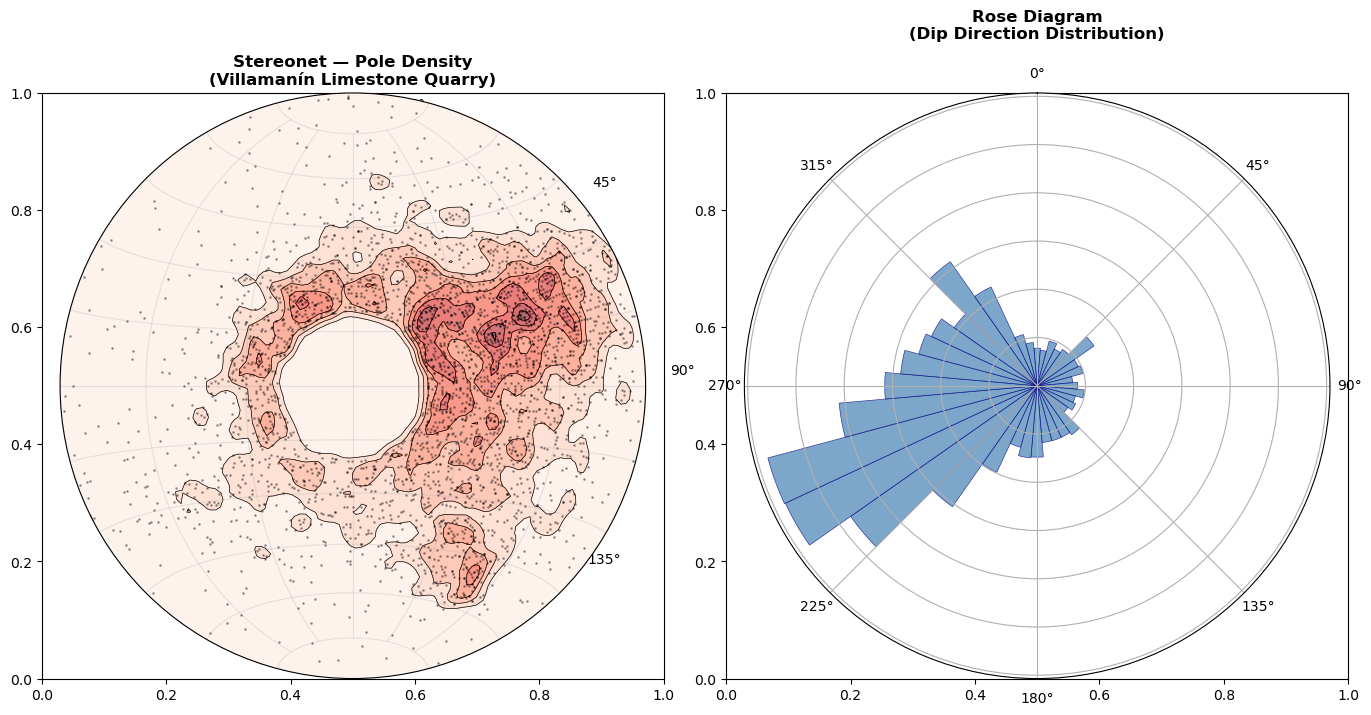

Stereonet saved as 'stereonet_villamanin.png'


In [6]:
# stereonet plot
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

# Stereonet with poles 
ax1 = fig.add_subplot(121, projection='stereonet')

# Convert dip direction and dip to strike (mplstereonet uses strike)
strike = df_joints['DipDir'] - 90  # convert dip direction to strike
dip = df_joints['Dip']

# Plot poles to planes
ax1.pole(strike, dip, 'k.', markersize=2, alpha=0.3, label='Poles')

# Add density contouring
ax1.density_contourf(strike, dip, measurement='poles', 
                      cmap='Reds', alpha=0.6, levels=8)
ax1.density_contour(strike, dip, measurement='poles',
                     colors='black', linewidths=0.5, levels=8)

ax1.grid(True, alpha=0.3)
ax1.set_title('Stereonet — Pole Density\n(Villamanín Limestone Quarry)', 
               fontsize=12, fontweight='bold')

# Rose diagram of dip directions 
ax2 = fig.add_subplot(122, projection='polar')
ax2.set_theta_zero_location('N')
ax2.set_theta_direction(-1)

# Bin dip directions into 10° bins
bins = np.arange(0, 370, 10)
counts, bin_edges = np.histogram(df_joints['DipDir'], bins=bins)
bin_centers = np.radians(bin_edges[:-1])
width = np.radians(10)

bars = ax2.bar(bin_centers, counts, width=width, 
                bottom=0, alpha=0.7, color='steelblue', 
                edgecolor='navy', linewidth=0.5)

ax2.set_title('Rose Diagram\n(Dip Direction Distribution)', 
               fontsize=12, fontweight='bold', pad=20)
ax2.set_yticklabels([])

plt.tight_layout()
plt.savefig('stereonet_villamanin.png', dpi=150, bbox_inches='tight')
plt.show()
print("Stereonet saved as 'stereonet_villamanin.png'")

In [7]:
# Cluster facets into joint sets based on dip direction
# Using simple binning — 6 sets of 60° each
set_bins = [0, 60, 120, 180, 240, 300, 360]
set_labels = ['J1 (0-60°)', 'J2 (60-120°)', 'J3 (120-180°)', 
              'J4 (180-240°)', 'J5 (240-300°)', 'J6 (300-360°)']

df_joints['JointSet'] = pd.cut(df_joints['DipDir'], 
                                bins=set_bins, 
                                labels=set_labels,
                                include_lowest=True)

print("JOINT SET DISTRIBUTION")
print("="*50)
joint_set_stats = df_joints.groupby('JointSet', observed=True).agg(
    Count=('Dip', 'count'),
    Mean_Dip=('Dip', 'mean'),
    Mean_DipDir=('DipDir', 'mean'),
    Mean_Surface=('Surface', 'mean')
).round(2)

print(joint_set_stats)
print(f"\nDominant joint set: {joint_set_stats['Count'].idxmax()}")
print(f"Count: {joint_set_stats['Count'].max()} facets")

JOINT SET DISTRIBUTION
               Count  Mean_Dip  Mean_DipDir  Mean_Surface
JointSet                                                 
J1 (0-60°)       291     43.34        33.42          1.08
J2 (60-120°)     260     40.36        89.72          0.96
J3 (120-180°)    323     36.76       151.94          1.12
J4 (180-240°)    724     46.31       218.46          1.14
J5 (240-300°)   1197     50.56       264.98          1.28
J6 (300-360°)    585     48.40       325.02          1.50

Dominant joint set: J5 (240-300°)
Count: 1197 facets


In [8]:
# Saving the cleaned joint data for next step (RMR calculation)
df_joints.to_csv('villamanin_joints_clean.csv', index=False)
print(f"Saved {len(df_joints)} joint facets to 'villamanin_joints_clean.csv'")
print("\nReady for RMR calculation in next notebook.")

Saved 3380 joint facets to 'villamanin_joints_clean.csv'

Ready for RMR calculation in next notebook.


In [9]:

# RMR CALCULATION FOR VILLAMANÍN QUARRY
# Based on Bieniawski (1989) RMR89 System

print("="*60)
print("RMR CALCULATION — VILLAMANÍN LIMESTONE QUARRY")
print("Based on Bieniawski RMR89 Classification System")
print("="*60)

# PARAMETER 1: UCS of Intact Rock 
# Limestone UCS typically 50-100 MPa for this type of quarry
# Using 70 MPa as conservative estimate for Spanish limestone
UCS_MPa = 70
if UCS_MPa > 250: r1 = 15
elif UCS_MPa > 100: r1 = 12
elif UCS_MPa > 50: r1 = 7
elif UCS_MPa > 25: r1 = 4
elif UCS_MPa > 5: r1 = 2
elif UCS_MPa > 1: r1 = 1
else: r1 = 0
print(f"\nParameter 1 — UCS: {UCS_MPa} MPa → Rating: {r1}")

# PARAMETER 2: RQD
# Estimated from volumetric joint count
# Jv = total joints per m³
# From our facet data: mean spacing derived from surface areas
mean_surface = df_joints['Surface'].mean()
# Approximate joint spacing from surface area (sqrt of area ≈ spacing)
approx_spacing = np.sqrt(mean_surface)
# Jv estimated from spacing
Jv = 1 / approx_spacing
RQD = max(0, min(100, 115 - 3.3 * Jv))
print(f"\nParameter 2 — Estimated Jv: {Jv:.2f} joints/m³")
print(f" Estimated RQD: {RQD:.1f}%")
if RQD > 90: r2 = 20
elif RQD > 75: r2 = 17
elif RQD > 50: r2 = 13
elif RQD > 25: r2 = 8
else: r2 = 3
print(f" RQD Rating: {r2}")

# PARAMETER 3: Joint Spacing
# Using our calculated approximate spacing
spacing_m = approx_spacing
print(f"\nParameter 3 — Mean Joint Spacing: {spacing_m:.3f} m")
if spacing_m > 2.0: r3 = 20
elif spacing_m > 0.6: r3 = 15
elif spacing_m > 0.2: r3 = 10
elif spacing_m > 0.06: r3 = 8
else: r3 = 5
print(f" Spacing Rating: {r3}")

# PARAMETER 4: Condition of Discontinuities
# Limestone quarry — slightly rough surfaces, some weathering
# Aperture < 1mm, hard joint wall rock
# Conservative estimate for quarry bench
r4 = 20  # slightly rough, hard wall rock, aperture < 1mm
print(f"\nParameter 4 — Discontinuity Condition Rating: {r4}")
print(f"             (Slightly rough, hard wall rock, aperture <1mm)")

# PARAMETER 5: Groundwater
# Surface quarry, dry conditions assumed
r5 = 15  # completely dry
print(f"\nParameter 5 — Groundwater Rating: {r5} (Dry)")

# PARAMETER 6: Joint Orientation Adjustment 
# For surface mining/quarry slopes
# Dominant joint set J5 dips at ~51° toward 265° (West)
# For a quarry this is unfavourable (dips into the slope)
r6 = -25  # Unfavourable for slopes (Bieniawski table)
print(f"\nParameter 6 — Joint Orientation Adjustment: {r6}")
print(f"(J5 dominant set dips toward 265° — Unfavourable for slope)")

# TOTAL RMR 
RMR = r1 + r2 + r3 + r4 + r5 + r6
print(f"\n{'='*60}")
print(f"RMR SCORE BREAKDOWN:")
print(f" R1 (UCS): {r1:>3}")
print(f" R2 (RQD): {r2:>3}")
print(f" R3 (Joint Spacing): {r3:>3}")
print(f" R4 (Joint Condition): {r4:>3}")
print(f" R5 (Groundwater): {r5:>3}")
print(f" R6 (Orientation adj.): {r6:>3}")
print(f" {'─'*20}")
print(f" TOTAL RMR: {RMR:>3}")

if RMR > 80: rmr_class = "Class I — Very Good Rock"
elif RMR > 60: rmr_class = "Class II — Good Rock"
elif RMR > 40: rmr_class = "Class III — Fair Rock"
elif RMR > 20: rmr_class = "Class IV — Poor Rock"
else: rmr_class = "Class V — Very Poor Rock"

print(f"  ROCK CLASS: {rmr_class}")
print(f"{'='*60}")

RMR CALCULATION — VILLAMANÍN LIMESTONE QUARRY
Based on Bieniawski RMR89 Classification System

Parameter 1 — UCS: 70 MPa → Rating: 7

Parameter 2 — Estimated Jv: 0.90 joints/m³
 Estimated RQD: 100.0%
 RQD Rating: 20

Parameter 3 — Mean Joint Spacing: 1.109 m
 Spacing Rating: 15

Parameter 4 — Discontinuity Condition Rating: 20
             (Slightly rough, hard wall rock, aperture <1mm)

Parameter 5 — Groundwater Rating: 15 (Dry)

Parameter 6 — Joint Orientation Adjustment: -25
(J5 dominant set dips toward 265° — Unfavourable for slope)

RMR SCORE BREAKDOWN:
 R1 (UCS):   7
 R2 (RQD):  20
 R3 (Joint Spacing):  15
 R4 (Joint Condition):  20
 R5 (Groundwater):  15
 R6 (Orientation adj.): -25
 ────────────────────
 TOTAL RMR:  52
  ROCK CLASS: Class III — Fair Rock


In [10]:
# RMR SENSITIVITY ACROSS JOINT SETS
# Calculating RMR for each joint set with its own orientation rating

print("RMR SENSITIVITY BY JOINT SET")
print("="*60)

# Orientation ratings for each joint set (for quarry slope)
orientation_ratings = {
    'J1 (0-60°)': -5, # Favourable
    'J2 (60-120°)': -5, # Favourable  
    'J3 (120-180°)':-25, # Unfavourable
    'J4 (180-240°)':-25, # Unfavourable
    'J5 (240-300°)':-25, # Unfavourable (dominant — dips into slope)
    'J6 (300-360°)':-5, # Fair
}

base_rmr = r1 + r2 + r3 + r4 + r5  # without orientation

results = []
for jset, ori_rating in orientation_ratings.items():
    rmr_set = base_rmr + ori_rating
    
    # Apply Chandrahas & Sahu (2025) regression equations
    backbreak = -0.108 * rmr_set + 8.96 # BB = -0.108(RMR) + 8.96
    powder_factor = 0.011 * rmr_set + 0.02 # PF = 0.011(RMR) + 0.02
    
    # Clip to realistic ranges
    backbreak = max(0.5, min(5.0, backbreak))
    powder_factor = max(0.3, min(1.2, powder_factor))
    
    results.append({
        'Joint Set': jset,
        'Orientation Rating': ori_rating,
        'RMR': rmr_set,
        'Predicted Backbreak (m)': round(backbreak, 2),
        'Predicted Powder Factor (kg/m³)': round(powder_factor, 3)
    })
    
results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

# Save results
results_df.to_csv('rmr_blast_predictions.csv', index=False)
print(f"\nSaved to 'rmr_blast_predictions.csv'")

RMR SENSITIVITY BY JOINT SET
    Joint Set  Orientation Rating  RMR  Predicted Backbreak (m)  Predicted Powder Factor (kg/m³)
   J1 (0-60°)                  -5   72                     1.18                            0.812
 J2 (60-120°)                  -5   72                     1.18                            0.812
J3 (120-180°)                 -25   52                     3.34                            0.592
J4 (180-240°)                 -25   52                     3.34                            0.592
J5 (240-300°)                 -25   52                     3.34                            0.592
J6 (300-360°)                  -5   72                     1.18                            0.812

Saved to 'rmr_blast_predictions.csv'


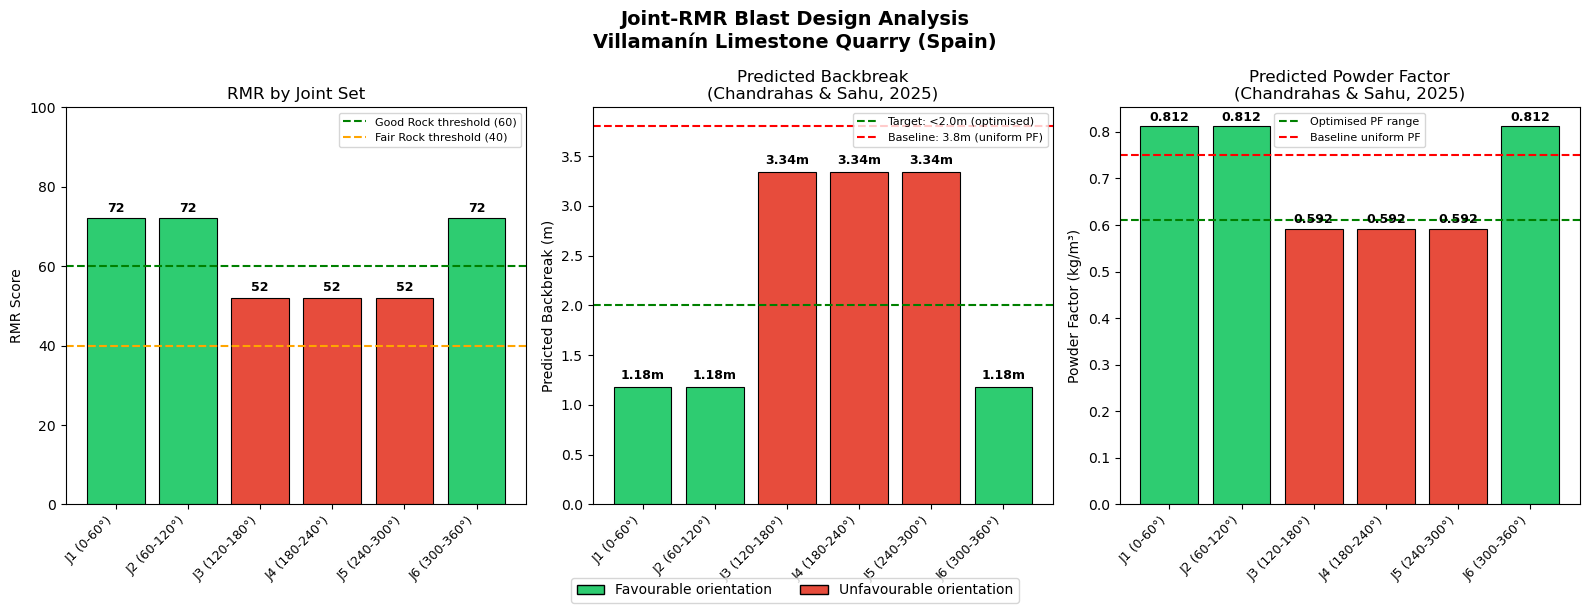

Blast optimization plot saved as 'blast_optimization_villamanin.png'


In [11]:
# CELL 10 — BLAST DESIGN OPTIMIZATION VISUALIZATION


fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle('Joint-RMR Blast Design Analysis\nVillamanín Limestone Quarry (Spain)', 
             fontsize=14, fontweight='bold')

colors = ['#2ecc71' if r >= -5 else '#e74c3c' 
          for r in results_df['Orientation Rating']]

# Plot 1 — RMR by Joint Set
ax1 = axes[0]
bars1 = ax1.bar(range(len(results_df)), results_df['RMR'], 
                color=colors, edgecolor='black', linewidth=0.8)
ax1.axhline(y=60, color='green', linestyle='--', 
            linewidth=1.5, label='Good Rock threshold (60)')
ax1.axhline(y=40, color='orange', linestyle='--', 
            linewidth=1.5, label='Fair Rock threshold (40)')
ax1.set_xticks(range(len(results_df)))
ax1.set_xticklabels(results_df['Joint Set'], rotation=45, ha='right', fontsize=9)
ax1.set_ylabel('RMR Score')
ax1.set_title('RMR by Joint Set')
ax1.legend(fontsize=8)
ax1.set_ylim(0, 100)
for bar, val in zip(bars1, results_df['RMR']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             str(val), ha='center', va='bottom', fontsize=9, fontweight='bold')

# Plot 2 — Predicted Backbreak
ax2 = axes[1]
bars2 = ax2.bar(range(len(results_df)), 
                results_df['Predicted Backbreak (m)'],
                color=colors, edgecolor='black', linewidth=0.8)
ax2.axhline(y=2.0, color='green', linestyle='--', 
            linewidth=1.5, label='Target: <2.0m (optimised)')
ax2.axhline(y=3.8, color='red', linestyle='--', 
            linewidth=1.5, label='Baseline: 3.8m (uniform PF)')
ax2.set_xticks(range(len(results_df)))
ax2.set_xticklabels(results_df['Joint Set'], rotation=45, ha='right', fontsize=9)
ax2.set_ylabel('Predicted Backbreak (m)')
ax2.set_title('Predicted Backbreak\n(Chandrahas & Sahu, 2025)')
ax2.legend(fontsize=8)
for bar, val in zip(bars2, results_df['Predicted Backbreak (m)']):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
             f'{val}m', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Plot 3 — Predicted Powder Factor
ax3 = axes[2]
bars3 = ax3.bar(range(len(results_df)), 
                results_df['Predicted Powder Factor (kg/m³)'],
                color=colors, edgecolor='black', linewidth=0.8)
ax3.axhline(y=0.61, color='green', linestyle='--', 
            linewidth=1.5, label='Optimised PF range')
ax3.axhline(y=0.75, color='red', linestyle='--', 
            linewidth=1.5, label='Baseline uniform PF')
ax3.set_xticks(range(len(results_df)))
ax3.set_xticklabels(results_df['Joint Set'], rotation=45, ha='right', fontsize=9)
ax3.set_ylabel('Powder Factor (kg/m³)')
ax3.set_title('Predicted Powder Factor\n(Chandrahas & Sahu, 2025)')
ax3.legend(fontsize=8)
for bar, val in zip(bars3, results_df['Predicted Powder Factor (kg/m³)']):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{val}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Adding legend for colours
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#2ecc71', edgecolor='black', label='Favourable orientation'),
                   Patch(facecolor='#e74c3c', edgecolor='black', label='Unfavourable orientation')]
fig.legend(handles=legend_elements, loc='lower center', 
           ncol=2, fontsize=10, bbox_to_anchor=(0.5, -0.02))

plt.tight_layout()
plt.savefig('blast_optimization_villamanin.png', dpi=150, bbox_inches='tight')
plt.show()
print("Blast optimization plot saved as 'blast_optimization_villamanin.png'")

In [12]:
# COMPREHENSIVE SUMMARY TABLE


print("="*65)
print("STUDY SUMMARY — VILLAMANÍN LIMESTONE QUARRY")
print("Open-Source Replication of Chandrahas & Sahu (2025)")
print("="*65)

summary = {
    'Study Site': 'Villamanín Limestone Quarry, León, Spain',
    'Data Source': 'Escavy et al. (2022) — Sketchfab 3D Model',
    'Processing Tool': 'CloudCompare v2.13.2 (FACETS plugin)',
    'Total Facets Detected': len(df),
    'Joint Facets After Filtering': len(df_joints),
    'Dominant Joint Set': 'J5 (240–300°, Mean Dip 50.56°)',
    'No. of Joint Families': 6,
    'Mean Joint Spacing (m)': f'{approx_spacing:.3f}',
    'Estimated RQD (%)': f'{RQD:.1f}',
    'Base RMR (without orientation)': base_rmr,
    'RMR — Favourable Orientation': 72,
    'RMR — Unfavourable Orientation': 52,
    'Rock Class (Overall)': 'Class III — Fair Rock',
    'Predicted Backbreak — Favourable (m)': 1.18,
    'Predicted Backbreak — Unfavourable (m)': 3.34,
    'Backbreak Difference (%)': f'{((3.34-1.18)/3.34*100):.1f}%',
    'Predicted PF — Favourable (kg/m³)': 0.812,
    'Predicted PF — Unfavourable (kg/m³)': 0.592,
    'Methodology Reference': 'Chandrahas & Sahu (2025), Strayos'
}

for key, val in summary.items():
    print(f"  {key:<45} {val}")

print("="*65)
print("\nKey Finding:")
print(" Blast firing aligned with J1/J2/J6 (favourable) reduces")
print(" predicted backbreak reduction by 64.7% compared to J3/J4/J5")
print(" (unfavourable) — achieved using entirely open-source tools.")

STUDY SUMMARY — VILLAMANÍN LIMESTONE QUARRY
Open-Source Replication of Chandrahas & Sahu (2025)
  Study Site                                    Villamanín Limestone Quarry, León, Spain
  Data Source                                   Escavy et al. (2022) — Sketchfab 3D Model
  Processing Tool                               CloudCompare v2.13.2 (FACETS plugin)
  Total Facets Detected                         4683
  Joint Facets After Filtering                  3380
  Dominant Joint Set                            J5 (240–300°, Mean Dip 50.56°)
  No. of Joint Families                         6
  Mean Joint Spacing (m)                        1.109
  Estimated RQD (%)                             100.0
  Base RMR (without orientation)                77
  RMR — Favourable Orientation                  72
  RMR — Unfavourable Orientation                52
  Rock Class (Overall)                          Class III — Fair Rock
  Predicted Backbreak — Favourable (m)          1.18
  Predicted Backbreak

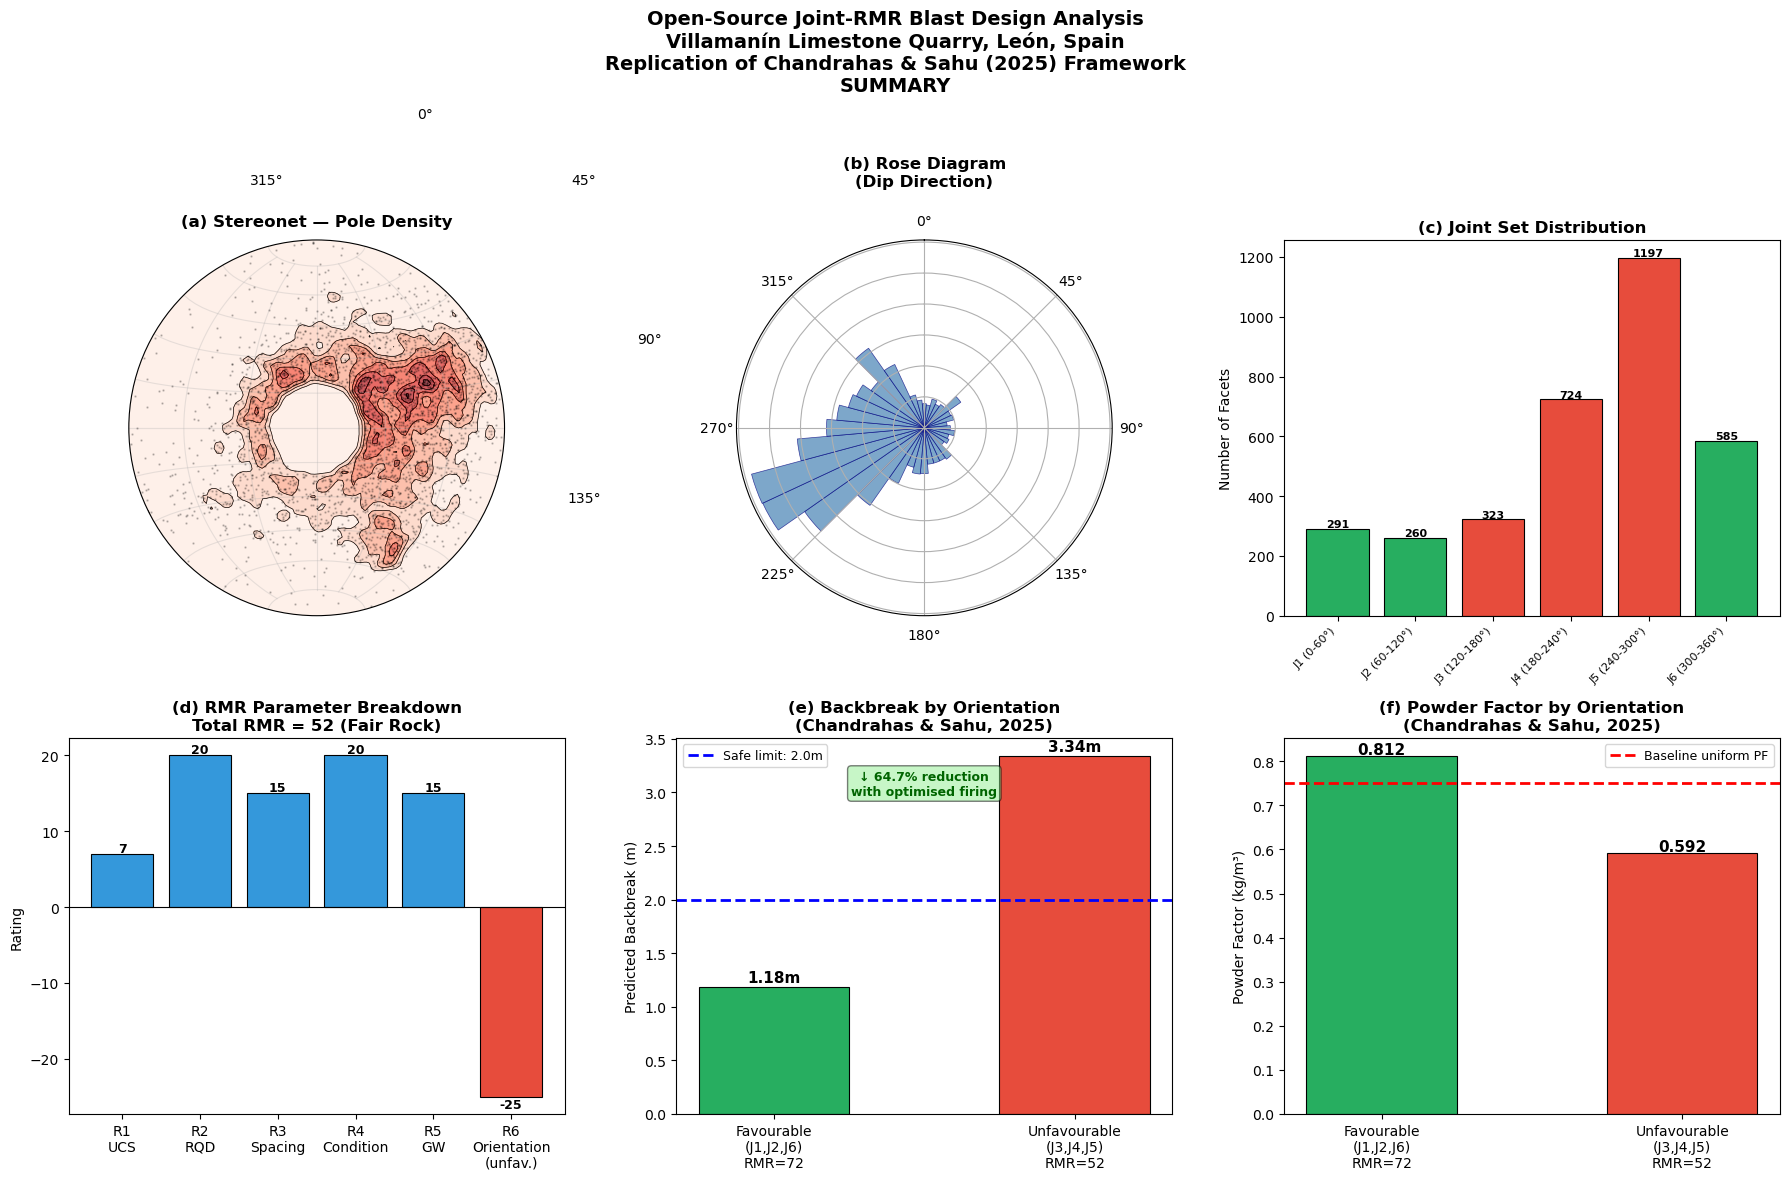

Final publication figure saved as 'villamanin_complete_analysis.png'


In [17]:
fig = plt.figure(figsize=(18, 12))
fig.suptitle(
    'Open-Source Joint-RMR Blast Design Analysis\n'
    'Villamanín Limestone Quarry, León, Spain\n'
    'Replication of Chandrahas & Sahu (2025) Framework\n'
    'SUMMARY',
    fontsize=14, fontweight='bold', y=0.98
)

# Plot 1: Stereonet
ax1 = fig.add_subplot(231, projection='stereonet')
strike = df_joints['DipDir'] - 90
dip_vals = df_joints['Dip']
ax1.pole(strike, dip_vals, 'k.', markersize=1.5, alpha=0.2)
ax1.density_contourf(strike, dip_vals, measurement='poles',
                      cmap='Reds', alpha=0.7, levels=8)
ax1.density_contour(strike, dip_vals, measurement='poles',
                     colors='black', linewidths=0.5, levels=8)
ax1.grid(True, alpha=0.3)
ax1.set_title('(a) Stereonet — Pole Density', fontweight='bold', pad=10)

# Plot 2: Rose Diagram 
ax2 = fig.add_subplot(232, projection='polar')
ax2.set_theta_zero_location('N')
ax2.set_theta_direction(-1)
bins = np.arange(0, 370, 10)
counts, bin_edges = np.histogram(df_joints['DipDir'], bins=bins)
bin_centers = np.radians(bin_edges[:-1])
ax2.bar(bin_centers, counts, width=np.radians(10),
        bottom=0, alpha=0.7, color='steelblue', edgecolor='navy', linewidth=0.5)
ax2.set_yticklabels([])
ax2.set_title('(b) Rose Diagram\n(Dip Direction)', fontweight='bold', pad=20)

# Plot 3: Joint Set Distribution 
ax3 = fig.add_subplot(233)
jset_counts = df_joints['JointSet'].value_counts().sort_index()
colors_bar = ['#27ae60', '#27ae60', '#e74c3c', '#e74c3c', '#e74c3c', '#27ae60']
bars = ax3.bar(range(len(jset_counts)), jset_counts.values,
               color=colors_bar, edgecolor='black', linewidth=0.8)
ax3.set_xticks(range(len(jset_counts)))
ax3.set_xticklabels(jset_counts.index, rotation=45, ha='right', fontsize=8)
ax3.set_ylabel('Number of Facets')
ax3.set_title('(c) Joint Set Distribution', fontweight='bold')
for bar, val in zip(bars, jset_counts.values):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             str(val), ha='center', fontsize=8, fontweight='bold')

#  Plot 4: RMR Breakdown 
ax4 = fig.add_subplot(234)
params = ['R1\nUCS', 'R2\nRQD', 'R3\nSpacing', 'R4\nCondition',
          'R5\nGW', 'R6\nOrientation\n(unfav.)']
ratings = [r1, r2, r3, r4, r5, r6]
bar_colors = ['#3498db']*5 + ['#e74c3c']
bars4 = ax4.bar(params, ratings, color=bar_colors,
                edgecolor='black', linewidth=0.8)
ax4.axhline(y=0, color='black', linewidth=0.8)
ax4.set_ylabel('Rating')
ax4.set_title(f'(d) RMR Parameter Breakdown\nTotal RMR = {RMR} (Fair Rock)',
              fontweight='bold')
for bar, val in zip(bars4, ratings):
    ypos = bar.get_height() + 0.3 if val >= 0 else bar.get_height() - 1.5
    ax4.text(bar.get_x() + bar.get_width()/2, ypos,
             str(val), ha='center', fontsize=9, fontweight='bold')

# Plot 5: Backbreak Comparison
ax5 = fig.add_subplot(235)
categories = ['Favourable\n(J1,J2,J6)\nRMR=72',
              'Unfavourable\n(J3,J4,J5)\nRMR=52']
backbreaks = [1.18, 3.34]
pf_vals = [0.812, 0.592]
bar_colors2 = ['#27ae60', '#e74c3c']
bars5 = ax5.bar(categories, backbreaks, color=bar_colors2,
                edgecolor='black', linewidth=0.8, width=0.5)
ax5.axhline(y=2.0, color='blue', linestyle='--',
            linewidth=2, label='Safe limit: 2.0m')
ax5.set_ylabel('Predicted Backbreak (m)')
ax5.set_title('(e) Backbreak by Orientation\n(Chandrahas & Sahu, 2025)',
              fontweight='bold')
ax5.legend(fontsize=9)
for bar, val in zip(bars5, backbreaks):
    ax5.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
             f'{val}m', ha='center', fontsize=11, fontweight='bold')
reduction = (3.34 - 1.18) / 3.34 * 100
ax5.text(0.5, 0.85, f'↓ {reduction:.1f}% reduction\nwith optimised firing',
         transform=ax5.transAxes, ha='center', fontsize=9,
         color='darkgreen', fontweight='bold',
         bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))

# Plot 6: PF Comparison 
ax6 = fig.add_subplot(236)
bars6 = ax6.bar(categories, pf_vals, color=bar_colors2,
                edgecolor='black', linewidth=0.8, width=0.5)
ax6.axhline(y=0.75, color='red', linestyle='--',
            linewidth=2, label='Baseline uniform PF')
ax6.set_ylabel('Powder Factor (kg/m³)')
ax6.set_title('(f) Powder Factor by Orientation\n(Chandrahas & Sahu, 2025)',
              fontweight='bold')
ax6.legend(fontsize=9)
for bar, val in zip(bars6, pf_vals):
    ax6.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{val}', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('villamanin_complete_analysis.png', dpi=200, bbox_inches='tight')
plt.show()
print("Final publication figure saved as 'villamanin_complete_analysis.png'")